In [24]:
import torch
import torch.nn as nn
import torchvision 
from torchvision.models import ResNet50_Weights
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

In [25]:
TRAIN_PATH = '../flower_dataset/train'
VAL_PATH = '../flower_dataset/valid'
TEST_PATH = '../flower_dataset/test'
BATCH_SIZE = 32
EPOCH = 40

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.5, 0.5, 0.5],
        std = [0.5, 0.5, 0.5]
    )
])

train_dataset = datasets.ImageFolder(root=TRAIN_PATH, transform=data_transform)
val_dataset = datasets.ImageFolder(root=VAL_PATH, transform=data_transform)
test_dataset = datasets.ImageFolder(root=TEST_PATH, transform=data_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [27]:
def build_variant(mode):
    if mode == 'scratch':
        model = torchvision.models.resnet50(weights=None)
    else:
        model = torchvision.models.resnet50(weights=ResNet50_Weights)

    model.fc = nn.Linear(model.fc.in_features, 102)

    for name, param in model.named_parameters():
        if mode == "frozen_transfer" and not name.startswith("fc."):
            param.requires_grad = False
        elif mode == "fine_tune" and not name.startswith(('fc.', 'layer3', 'layer4')):
            param.requires_grad = False

    return model.to(device)

In [28]:
def get_param_groups(model, mode):
    head_params = [p for n, p in model.named_parameters() if n.startswith("fc.") and p.requires_grad]
    backbone_params = [p for n, p in model.named_parameters() if not n.startswith("fc.") and p.requires_grad]

    if mode == 'frozen_transfer':
        return [
            {"params": head_params, "lr": 1e-3}
        ]
    elif mode == "scratch":
        return [
            {"params": backbone_params + head_params, "lr": 1e-3}
        ]
    else:
        return [
            {"params": backbone_params, "lr" : 1e-4},
            {"params": head_params, "lr": 1e-3}
        ]

In [29]:
modes = ['scratch', 'frozen_transfer', 'fine_tune', 'init']

train_loss_lists, val_loss_lists, train_acc_lists, val_acc_lists = [], [], [], []

for mode in modes:
    model = build_variant(mode)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(get_param_groups(model, mode))

    PATIENCE = 5
    best_val_loss = float("inf")
    patience_counter = 0

    train_loss_list, val_loss_list, train_acc_list, val_acc_list = [], [], [], []

    for epoch in range(EPOCH):
        train_loss_sum = 0
        train_correct = 0
        train_total = 0

        model.train()
            
        for images, labels in train_loader:

            images, labels = images.to(device), labels.to(device)    

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            train_loss_sum += loss.item()

            loss.backward()
            optimizer.step()

            predictions = outputs.argmax(dim=1)
            train_correct += (predictions == labels).sum().item()
            train_total += labels.size(0)

        train_loss = train_loss_sum / len(train_loader)
        train_acc = train_correct / train_total

        train_loss_list.append(train_loss)
        train_acc_list.append(train_acc)

        model.eval()

        val_loss_sum = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss_sum += loss.item()

                predictions = outputs.argmax(dim=1)
                val_correct += (predictions == labels).sum().item()
                val_total += labels.size(0)


        val_loss = val_loss_sum / len(val_loader)
        val_acc = val_correct / val_total

        val_loss_list.append(val_loss)
        val_acc_list.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0

            torch.save(model.state_dict(), f"{mode}_best_model.pth")

        else:
            patience_counter += 1

            if patience_counter >= PATIENCE:
                print("Early stopping.")
                break

    train_loss_lists.append(train_loss_list)
    val_loss_lists.append(val_loss_list)
    
    train_acc_lists.append(train_acc_list)
    val_acc_lists.append(val_acc_list)
    
        

Early stopping.
Early stopping.
Early stopping.
Early stopping.


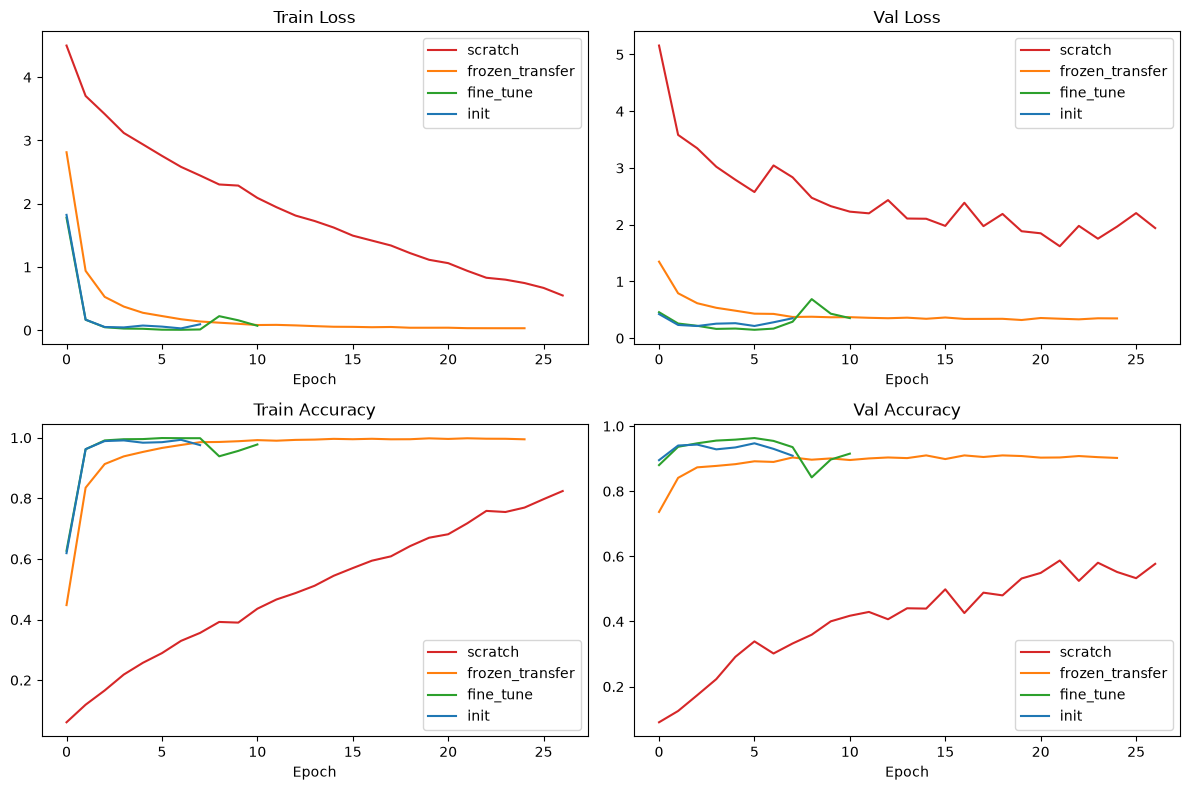

scratch: final val_acc = 0.5770, best val_acc = 0.5873
frozen_transfer: final val_acc = 0.9022, best val_acc = 0.9100
fine_tune: final val_acc = 0.9154, best val_acc = 0.9633
init: final val_acc = 0.9090, best val_acc = 0.9472


In [30]:
modes = ['scratch', 'frozen_transfer', 'fine_tune', 'init']
colors = ['tab:red', 'tab:orange', 'tab:green', 'tab:blue']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, mode in enumerate(modes):
    axes[0, 0].plot(train_loss_lists[i], label=mode, color=colors[i])
    axes[0, 1].plot(val_loss_lists[i], label=mode, color=colors[i])
    axes[1, 0].plot(train_acc_lists[i], label=mode, color=colors[i])
    axes[1, 1].plot(val_acc_lists[i], label=mode, color=colors[i])

axes[0, 0].set_title("Train Loss")
axes[0, 1].set_title("Val Loss")
axes[1, 0].set_title("Train Accuracy")
axes[1, 1].set_title("Val Accuracy")

for ax in axes.flat:
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.savefig("transfer_learning_comparison.png", dpi=150)
plt.show()

for i, mode in enumerate(modes):
    print(f"{mode}: final val_acc = {val_acc_lists[i][-1]:.4f}, best val_acc = {max(val_acc_lists[i]):.4f}")

In [31]:
test_results = {}

for mode in modes:
    model = build_variant(mode)
    model.load_state_dict(torch.load(f"{mode}_best_model.pth"))
    model.eval()

    test_correct = 0
    test_total = 0
    test_loss_sum = 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss_sum += loss.item()
            predictions = outputs.argmax(dim=1)
            test_correct += (predictions == labels).sum().item()
            test_total += labels.size(0)

    test_loss = test_loss_sum / len(test_loader)
    test_acc = test_correct / test_total
    test_results[mode] = {"test_loss": test_loss, "test_acc": test_acc}

    print(f"{mode}: test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

scratch: test_loss=1.6285, test_acc=0.5833
frozen_transfer: test_loss=0.3290, test_acc=0.9016
fine_tune: test_loss=0.1139, test_acc=0.9691
init: test_loss=0.1865, test_acc=0.9505
